In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Thesis-ready style ──────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "sans-serif",
    "font.size":          15,
    "axes.titlesize":     15,
    "axes.titleweight":   "bold",
    "axes.labelsize":     15,
    "xtick.labelsize":    15,
    "ytick.labelsize":    15,
    "legend.fontsize":    15,
    "legend.framealpha":  0.85,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "axes.grid.axis":     "y",
    "grid.alpha":         0.35,
    "grid.linestyle":     "--",
    "figure.dpi":         120,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
})

# Wong colorblind-safe palette
COLORS = {
    "No Instability": "#0072B2",   # blue
    "Instability":    "#D55E00",   # vermillion
    "Stance":         "#0072B2",
    "Walk":           "#E69F00",   # golden yellow
}

DATASET_LABELS = {
    "omnia_park": "Omnia Park",
    "kiel":       "Kiel",
    "wearpd":     "WearPD",
}

OUTPUT_DIR = "figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
df_raw = pd.read_csv("cnn_gru/data/metadata.csv")

In [3]:
# unique number of subjects per dataset
dataset_unique_subjects = df_raw.groupby("dataset")["subjectID"].nunique()
print("Unique subjects per dataset:")
for dataset, count in dataset_unique_subjects.items():
    print(f"  {DATASET_LABELS.get(dataset, dataset)}: {count}")

Unique subjects per dataset:
  Kiel: 17
  Omnia Park: 39
  WearPD: 94


In [4]:
def stacked_bar(ax, df_pct, color_map, ylabel="Subjects (%)"):
    """Draw a stacked percentage bar chart with in-bar labels."""
    cols = list(df_pct.columns)
    x = np.arange(len(df_pct))
    width = 0.55
    bottoms = np.zeros(len(df_pct))

    for col in cols:
        vals = df_pct[col].values
        bars = ax.bar(x, vals, bottom=bottoms, color=color_map[col],
                      label=col, width=width, zorder=3)
        for j, (val, bot) in enumerate(zip(vals, bottoms)):
            if val > 6:
                ax.text(x[j], bot + val / 2, f"{val:.0f}%",
                        ha="center", va="center",
                        color="white", fontsize=15, fontweight="bold", zorder=4)
        bottoms += vals

    ax.set_xticks(x)
    ax.set_xticklabels(df_pct.index)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 108)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.3), ncol=len(cols), frameon=True)

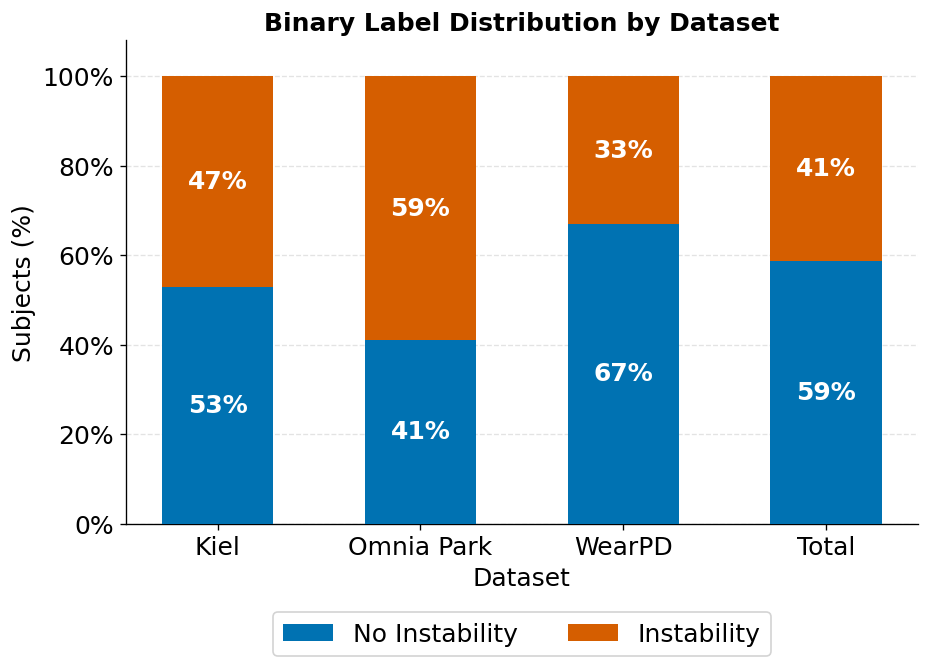

In [5]:
df_cls = df_raw.copy()
df_cls["label_binary"] = df_cls["label"].map(
    {0: "No Instability", 1: "Instability", 2: "Instability", 3: "Instability"}
)
df_subjects = df_cls.drop_duplicates(subset=["subjectID", "dataset"])

dataset_counts = df_subjects.groupby(["dataset", "label_binary"]).size().unstack(fill_value=0)
dataset_pct    = dataset_counts.div(dataset_counts.sum(axis=1), axis=0) * 100

total_counts = df_subjects.groupby("label_binary").size()
dataset_pct.loc["Total"] = (total_counts / total_counts.sum()) * 100

dataset_pct.index = [DATASET_LABELS.get(i, i.title()) for i in dataset_pct.index]
# Ensure consistent column order
dataset_pct = dataset_pct[["No Instability", "Instability"]]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
stacked_bar(ax, dataset_pct, COLORS)
ax.set_xlabel("Dataset")
ax.set_title("Binary Label Distribution by Dataset")
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/label_distribution.pdf")
fig.savefig(f"{OUTPUT_DIR}/label_distribution.png")
plt.show()

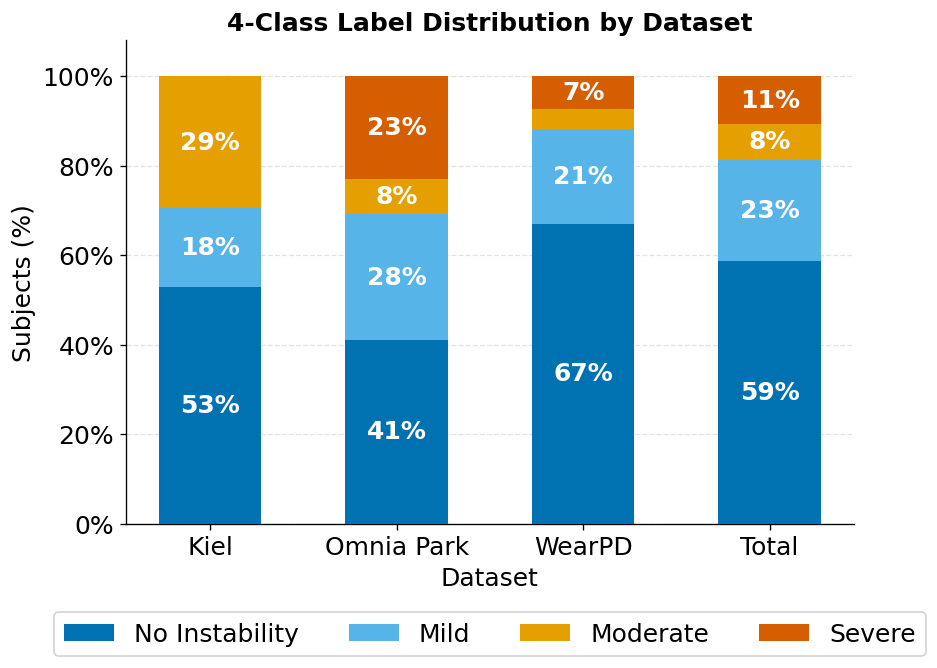

In [6]:
LABEL_NAMES_4 = {0: "No Instability", 1: "Mild", 2: "Moderate", 3: "Severe"}
COLORS_4 = {
    "No Instability": "#0072B2",   # blue
    "Mild":           "#56B4E9",   # sky blue
    "Moderate":       "#E69F00",   # golden yellow
    "Severe":         "#D55E00",   # vermillion
}

df4 = df_raw.copy()
df4["label"] = df4["label"].map(LABEL_NAMES_4)
df_subjects4 = df4.drop_duplicates(subset=["subjectID", "dataset"])

dataset_counts = df_subjects4.groupby(["dataset", "label"]).size().unstack(fill_value=0)
dataset_pct    = dataset_counts.div(dataset_counts.sum(axis=1), axis=0) * 100

total_counts = df_subjects4.groupby("label").size()
dataset_pct.loc["Total"] = (total_counts / total_counts.sum()) * 100

dataset_pct.index = [DATASET_LABELS.get(i, i.title()) for i in dataset_pct.index]
label_order = [LABEL_NAMES_4[i] for i in [0, 1, 2, 3]]
dataset_pct = dataset_pct[label_order]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
stacked_bar(ax, dataset_pct, COLORS_4)
ax.set_xlabel("Dataset")
ax.set_title("4-Class Label Distribution by Dataset")
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/label_distribution_4cls.pdf")
fig.savefig(f"{OUTPUT_DIR}/label_distribution_4cls.png")
plt.show()


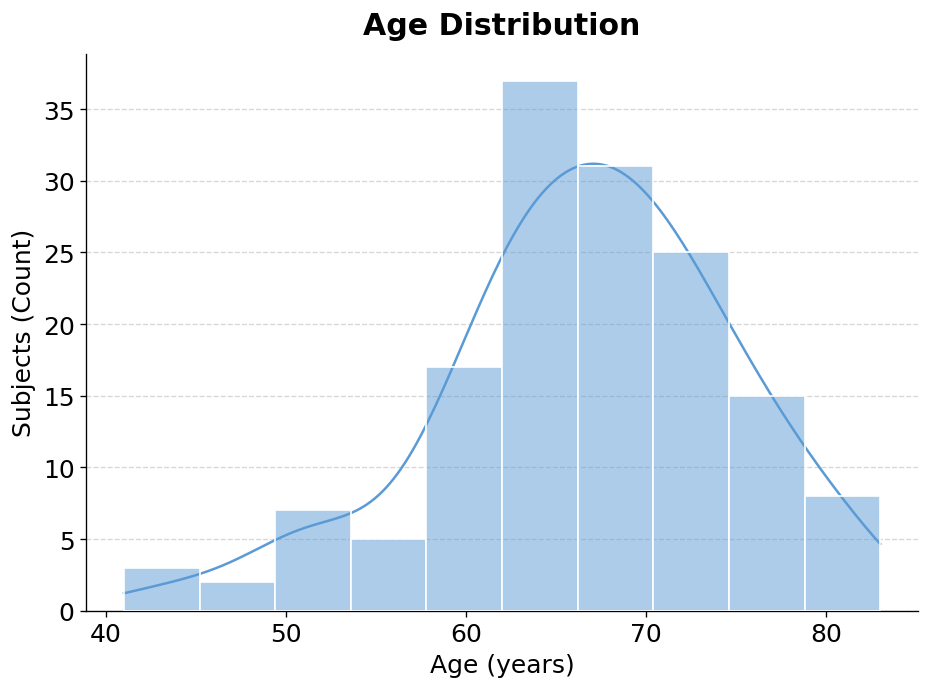

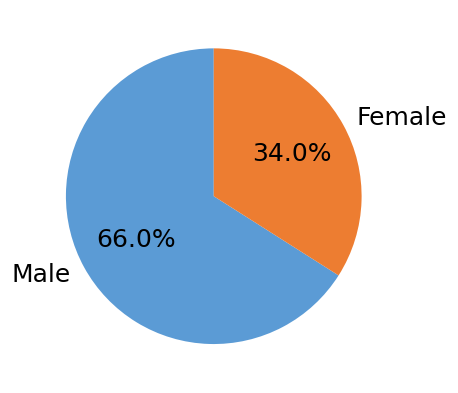

In [7]:
C_PRIMARY = "#5B9BD5"  # Soft Blue
C_ACCENT = "#ED7D31"   # Soft Orange/Coral

# ── Data Preparation (Subject-wise) ──────────────────────────────────────────
df_cls = df_raw.copy()
df_subjects = df_cls.drop_duplicates(subset=["subjectID", "dataset"]).copy()

# Ensure types are correct for plotting
df_subjects['age'] = pd.to_numeric(df_subjects['age'], errors='coerce')


# ── FIGURE 1: Age Distribution ────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 6))

# Draw the histogram with an explicit styling overlay
sns.histplot(
    data=df_subjects, 
    x='age', 
    kde=True, 
    color=C_PRIMARY, 
    ax=ax1, 
    bins=10,
    zorder=3,
    edgecolor='white',
    linewidth=1
)

# Apply consistent axes styling
ax1.set_title("Age Distribution", fontsize=18, fontweight="bold", pad=12)
ax1.set_xlabel("Age (years)", fontsize=15)
ax1.set_ylabel("Subjects (Count)", fontsize=15)
ax1.grid(True, axis='y', linestyle='--', alpha=0.5, zorder=0)

# Polish edges and formatting
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.tick_params(labelsize=15)

fig1.tight_layout()
fig1.savefig(f"{OUTPUT_DIR}/age_distribution.pdf", bbox_inches='tight')
fig1.savefig(f"{OUTPUT_DIR}/age_distribution.png", bbox_inches='tight', dpi=300)


# ── FIGURE 2: Gender Distribution ─────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(6, 4))
# map M: Male, F: Female
df_subjects['gender'] = df_subjects['gender'].map({'M': 'Male', 'F': 'Female'})
# Group data and compute percentages to match the format of your stacked bar
gender_counts = df_subjects['gender'].value_counts().sort_values(ascending=False)
gender_pct = (gender_counts / gender_counts.sum()) * 100

x_gen = np.arange(len(gender_pct))
width_gen = 0.55

# pie chart for gender
ax2.pie(gender_pct.values, labels=gender_pct.index, autopct='%1.1f%%', colors=[C_PRIMARY, C_ACCENT][:len(gender_pct)], startangle=90)
# save the pie chart as a separate figure
fig2.savefig(f"{OUTPUT_DIR}/gender_distribution.pdf", bbox_inches='tight')
fig2.savefig(f"{OUTPUT_DIR}/gender_distribution.png", bbox_inches='tight', dpi=300)